In [79]:
import numpy as np
import functools
import pickle
import torch
from matplotlib import pyplot as pp
import time

with open('/Users/anshgrover/AIDA3/PINN-tutorial/data/massdamper_data.pkl', 'rb') as f:
    data = pickle.load(f)

data_sampled_random_with_noise = data['data_sampled_random_with_noise']
model_name = 'No external force'
sparsity = 'sparsity 1.667Hz'

t_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['t'], dtype=torch.float64)
y_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['x'], dtype=torch.float64)

n = len(t_obs)
p = 1
print(n)

100


In [80]:
m_true      = 2.0
c_true      = 0.3
k_true      = 0.2
delta_true  = c_true / (2 * m_true)
omega0_true = np.sqrt(k_true / m_true)

x0    = [y_obs[0].item(), 0.0]   # first observed state, velocity fixed at 0
sigma = 0.1                       # known noise std
R     = sigma ** 2                # known noise variance

print(f"true delta  = {delta_true:.4f}")
print(f"true omega0 = {omega0_true:.4f}")
print(f"x0          = {x0}")
print(f"R           = {R}")

true delta  = 0.0750
true omega0 = 0.3162
x0          = [1.0302449714360125, 0.0]
R           = 0.010000000000000002


m_sub=11  step_size=0.0546s


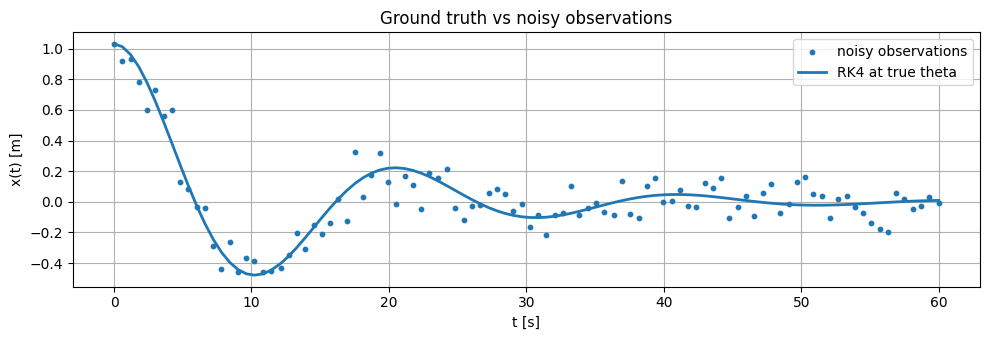

In [81]:
from scipy.integrate import solve_ivp

def msd_scipy(t, y, delta, omega0):
    x, v = y
    return [v, -2*delta*v - omega0**2*x]

K              = 4
h              = (t_obs[1] - t_obs[0]).item()
theorem2_bound = n ** (-5 / (2 * K))
m_sub          = int(np.ceil(h / theorem2_bound))
step_size      = h / m_sub
print(f"m_sub={m_sub}  step_size={step_size:.4f}s")

sol_true = solve_ivp(msd_scipy, (t_obs[0].item(), t_obs[-1].item()), x0,
                     t_eval=t_obs.numpy(), method='RK45', max_step=step_size,
                     args=(delta_true, omega0_true))

x_pred = sol_true.y[0]

pp.figure(figsize=(10, 3.5))
pp.scatter(t_obs, y_obs, s=10, label='noisy observations', zorder=3)
pp.plot(t_obs, x_pred, lw=2, label='RK4 at true theta')
pp.xlabel('t [s]'); pp.ylabel('x(t) [m]')
pp.title('Ground truth vs noisy observations')
pp.legend(); pp.grid(True); pp.tight_layout(); pp.show()

In [82]:
# theta = theta_prior + D @ z,  z ~ N(0, I)
theta_prior = torch.tensor([0.10, 0.35], dtype=torch.float64)
D           = torch.diag(torch.tensor([0.20, 0.40], dtype=torch.float64))
# Rerun optimizer and check if theta_MAP is the same

# sanity check: where does true theta sit in z-space?
theta_true_t = torch.tensor([delta_true, omega0_true], dtype=torch.float64)
z_true       = torch.linalg.solve(D, theta_true_t - theta_prior)

print(f"theta_prior = {theta_prior.numpy()}")
print(f"D scales    = {torch.diag(D).numpy()}")
print(f"z_true      = {z_true.numpy()}  (should be O(1))")

theta_prior = [0.1  0.35]
D scales    = [0.2 0.4]
z_true      = [-0.125      -0.08443058]  (should be O(1))


In [83]:
def msd(t, y, delta, omega0):
    if not torch.is_tensor(y):
        y = torch.tensor(y, dtype=torch.float64)
    x, v = y[0], y[1]
    return torch.stack([v, -2*delta*v - omega0**2*x])

def rk4_integrate(f, t_eval, y0, m_sub):
    if not torch.is_tensor(y0):
        y0 = torch.tensor(y0, dtype=torch.float64)
    if not torch.is_tensor(t_eval):
        t_eval = torch.tensor(t_eval, dtype=torch.float64)
    Y = [y0]
    y = y0
    for i in range(1, len(t_eval)):
        dt = (t_eval[i] - t_eval[i-1]).item()
        h  = dt / m_sub
        yi = y
        ti = t_eval[i-1].item()
        for _ in range(m_sub):
            k1 = f(ti,       yi            )
            k2 = f(ti + h/2, yi + h/2 * k1)
            k3 = f(ti + h/2, yi + h/2 * k2)
            k4 = f(ti + h,   yi + h   * k3)
            yi = yi + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
            ti += h
        y = yi
        Y.append(y)
    return torch.stack(Y)

In [84]:
def J(z):
    theta  = theta_prior + D @ z
    delta  = theta[0]
    omega0 = theta[1]

    f      = lambda t, y: msd(t, y, delta, omega0)
    Y      = rk4_integrate(f, t_obs, x0, m_sub)
    y_pred = Y[:, 0]

    J_data  = (1.0 / (2 * n * R)) * torch.sum((y_obs - y_pred) ** 2)
    J_prior = 0.5 * torch.dot(z, z)

    return J_data + J_prior

# sanity check
theta_true_t = torch.tensor([delta_true, omega0_true], dtype=torch.float64)
z_true       = torch.linalg.solve(D, theta_true_t - theta_prior)
print(f"z_true    = {z_true.numpy()}")
print(f"J(z_true) = {J(z_true).item():.6f}")
print(f"J_data    = {(1.0/(n*R)*torch.sum((y_obs - torch.tensor(sol_true.y[0], dtype=torch.float64))**2)).item():.6f}")
print(f"J_prior   = {(0.5*torch.dot(z_true,z_true)).item():.6f}")

z_true    = [-0.125      -0.08443058]
J(z_true) = 0.484081
J_data    = 0.945409
J_prior   = 0.011377


In [85]:
# MAP optimization

t_start = time.time()

z = torch.zeros(2, dtype=torch.float64, requires_grad=True)
optimizer = torch.optim.LBFGS([z], lr=1.0, max_iter=500,
                               tolerance_grad=1e-9, tolerance_change=1e-12,
                               line_search_fn='strong_wolfe')

def closure():
    optimizer.zero_grad()
    loss = J(z)
    loss.backward()
    return loss

optimizer.step(closure)
t_map = time.time() - t_start

z_map     = z.detach().clone()
theta_map = (theta_prior + D @ z_map).detach()

print(f"\nMAP optimization time: {t_map:.2f}s")
print(f"z_MAP     = {z_map.numpy()}")
print(f"theta_MAP = {theta_map.numpy()}")
print(f"true theta= [{delta_true:.4f}, {omega0_true:.4f}]")


MAP optimization time: 3.15s
z_MAP     = [-0.06983671 -0.08330559]
theta_MAP = [0.08603266 0.31667777]
true theta= [0.0750, 0.3162]


In [86]:
# Hessian and Covariance

t_start = time.time()
H           = torch.autograd.functional.hessian(J, z_map)
t_hess      = time.time() - t_start

Sigma_z     = torch.linalg.inv(H)
Sigma_theta = D @ Sigma_z @ D.T

print(f"\nHessian time: {t_hess:.2f}s")
print(f"Total time:   {t_map + t_hess:.2f}s")
print(f"Sigma_theta =\n{Sigma_theta.detach().numpy()}")
print(f"posterior std delta  = {Sigma_theta[0,0].sqrt().item():.6f}")
print(f"posterior std omega0 = {Sigma_theta[1,1].sqrt().item():.6f}")


Hessian time: 1.63s
Total time:   4.78s
Sigma_theta =
[[0.0029804  0.00169124]
 [0.00169124 0.00304225]]
posterior std delta  = 0.054593
posterior std omega0 = 0.055157


In [87]:
# Sampling

N_samples = 1000
dist          = torch.distributions.MultivariateNormal(
                    theta_map.float(), Sigma_theta.float())
theta_samples = dist.sample((N_samples,)).double()

delta_samples  = theta_samples[:, 0].numpy()
omega0_samples = theta_samples[:, 1].numpy()

delta_ci  = np.percentile(delta_samples,  [2.5, 97.5])
omega0_ci = np.percentile(omega0_samples, [2.5, 97.5])

print(f"\nδ   95% CI: [{delta_ci[0]:.4f}, {delta_ci[1]:.4f}]  true={delta_true:.4f}")
print(f"ω₀  95% CI: [{omega0_ci[0]:.4f}, {omega0_ci[1]:.4f}]  true={omega0_true:.4f}")



δ   95% CI: [-0.0162, 0.1889]  true=0.0750
ω₀  95% CI: [0.2100, 0.4188]  true=0.3162


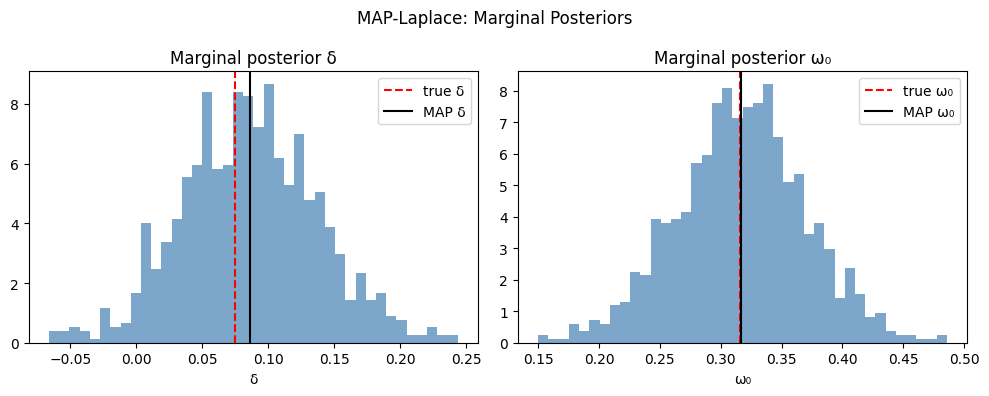

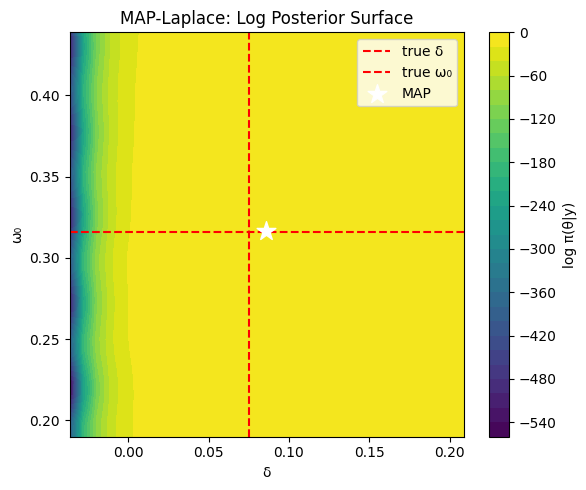

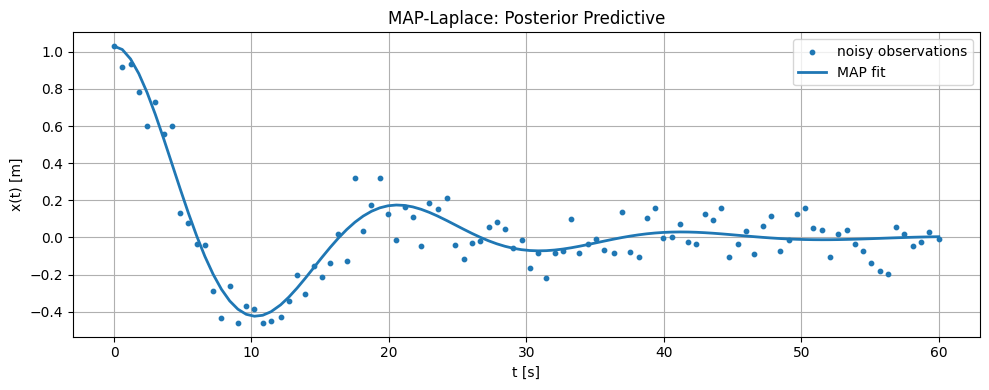


── Summary ──────────────────────────────────────
                          δ          ω₀
True                 0.0750      0.3162
MAP estimate         0.0860      0.3167
Posterior std        0.0546      0.0552
95% CI low          -0.0162      0.2100
95% CI high          0.1889      0.4188
Total time             4.78s


In [88]:
fig, axes = pp.subplots(1, 2, figsize=(10, 4))

axes[0].hist(delta_samples, bins=40, density=True, alpha=0.7, color='steelblue')
axes[0].axvline(delta_true,        color='r',  linestyle='--', label='true δ')
axes[0].axvline(theta_map[0].item(), color='k', linestyle='-',  label='MAP δ')
axes[0].set_xlabel('δ'); axes[0].set_title('Marginal posterior δ')
axes[0].legend()

axes[1].hist(omega0_samples, bins=40, density=True, alpha=0.7, color='steelblue')
axes[1].axvline(omega0_true,         color='r',  linestyle='--', label='true ω₀')
axes[1].axvline(theta_map[1].item(), color='k',  linestyle='-',  label='MAP ω₀')
axes[1].set_xlabel('ω₀'); axes[1].set_title('Marginal posterior ω₀')
axes[1].legend()

pp.suptitle('MAP-Laplace: Marginal Posteriors')
pp.tight_layout(); pp.show()

# --- 10.2 Posterior surface (contour) ---
delta_grid  = np.linspace(delta_ci[0] - 0.02, delta_ci[1] + 0.02, 30)
omega0_grid = np.linspace(omega0_ci[0] - 0.02, omega0_ci[1] + 0.02, 30)
DD, WW      = np.meshgrid(delta_grid, omega0_grid)
log_post    = np.zeros_like(DD)

for i in range(DD.shape[0]):
    for j in range(DD.shape[1]):
        theta_ij = torch.tensor([DD[i,j], WW[i,j]], dtype=torch.float64)
        z_ij     = torch.linalg.solve(D, theta_ij - theta_prior)
        with torch.no_grad():
            log_post[i, j] = -J(z_ij).item()

pp.figure(figsize=(6, 5))
pp.contourf(DD, WW, log_post, levels=30, cmap='viridis')
pp.colorbar(label='log π(θ|y)')
pp.axvline(delta_true,          color='r', linestyle='--', label='true δ')
pp.axhline(omega0_true,         color='r', linestyle='--', label='true ω₀')
pp.scatter(theta_map[0].item(), theta_map[1].item(),
           color='w', marker='*', s=200, zorder=5, label='MAP')
pp.xlabel('δ'); pp.ylabel('ω₀')
pp.title('MAP-Laplace: Log Posterior Surface')
pp.legend(); pp.tight_layout(); pp.show()

# --- 10.3 Posterior predictive ---
f_map  = lambda t, y: msd(t, y, theta_map[0], theta_map[1])
Y_map  = rk4_integrate(f_map, t_obs, x0, m_sub)

pp.figure(figsize=(10, 4))
pp.scatter(t_obs.numpy(), y_obs.numpy(), s=10,
           label='noisy observations', zorder=3)
pp.plot(t_obs.numpy(), Y_map[:, 0].detach().numpy(),
        lw=2, label='MAP fit')
pp.xlabel('t [s]'); pp.ylabel('x(t) [m]')
pp.title('MAP-Laplace: Posterior Predictive')
pp.legend(); pp.grid(True); pp.tight_layout(); pp.show()

# --- 10.4 Summary table ---
print("\n── Summary ──────────────────────────────────────")
print(f"{'':15s}  {'δ':>10s}  {'ω₀':>10s}")
print(f"{'True':15s}  {delta_true:>10.4f}  {omega0_true:>10.4f}")
print(f"{'MAP estimate':15s}  {theta_map[0].item():>10.4f}  {theta_map[1].item():>10.4f}")
print(f"{'Posterior std':15s}  {Sigma_theta[0,0].sqrt().item():>10.4f}  {Sigma_theta[1,1].sqrt().item():>10.4f}")
print(f"{'95% CI low':15s}  {delta_ci[0]:>10.4f}  {omega0_ci[0]:>10.4f}")
print(f"{'95% CI high':15s}  {delta_ci[1]:>10.4f}  {omega0_ci[1]:>10.4f}")
print(f"{'Total time':15s}  {t_map + t_hess:>10.2f}s")

In [89]:
print(omega0_true)
print(theta_map[1].item())

0.31622776601683794
0.31667776500850836


In [91]:
map_x_pred = Y_map[:,0].detach().numpy()

np.savez('map_results.npz',
    delta_samples  = theta_samples[:,0].numpy(),
    omega0_samples = theta_samples[:,1].numpy(),
    x_pred         = map_x_pred,
    theta_map      = theta_map.numpy(),
)